## Rationale for Using Multiple Datasets in a Fraud Detection System

The objective of this project is not only to detect fraudulent transactions, but also to understand the underlying factors that lead to such events. In particular, the system aims to capture both the **behavioral patterns of fraudulent transactions** and the **communication signals (e.g., messages or interactions) that may trigger them**.

To achieve this, two distinct datasets are utilized, each representing a different dimension of the fraud lifecycle:

* A **transactional dataset** is used to model and identify patterns associated with fraudulent financial activities.
* A **message-based dataset** (e.g., SMS or email) is used to analyze the content and characteristics of communications that may influence or initiate fraudulent behavior.

By integrating insights from both datasets, the project adopts a more comprehensive approach to fraud detection—one that considers not only "whether" a transaction is fraudulent, but also "why" it may have occurred. This dual-perspective framework enhances the system’s ability to provide deeper analytical insights and supports the development of more robust and interpretable fraud detection models.


In [ ]:
# Importing the necessary libraries for the project.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, TunedThresholdClassifierCV
import spacy
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Exploratory Data Analysis on Fraud Detection Dataset

In [ ]:
# This is the dataset for spam messages. The 'sm' means Spam Messages.

df_sm = pd.read_csv('email_spam.csv', encoding='latin1')

In [ ]:
df_sm

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df_sm = df_sm.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
columns = ['label', 'message']
df_sm.columns = columns

In [ ]:
df_sm.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df_sm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df_sm.isnull().sum()

,0
label,0
message,0


In [ ]:
df_sm.duplicated().sum()

np.int64(403)

In [ ]:
df_sm.drop_duplicates(inplace=True)

In [ ]:
df_sm.shape

(5169, 2)

In [ ]:
df_sm.size

10338

In [ ]:
# Counting the number of ham and spam in the label column.

df_sm['label'].value_counts()

,count
label,
ham,4516
spam,653


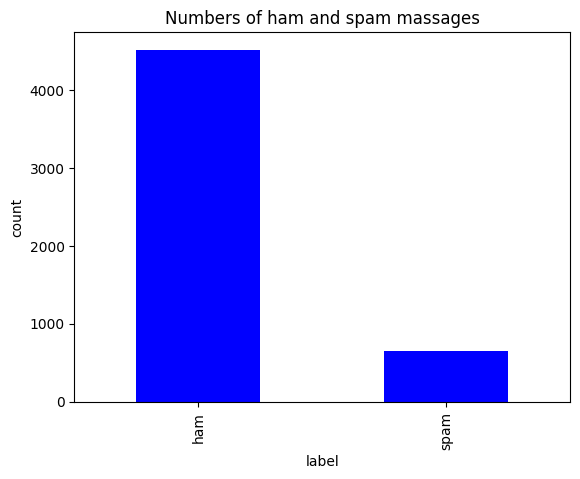

In [ ]:
df_sm['label'].value_counts().plot(kind='bar', title='Numbers of ham and spam massages', color='blue')
plt.xlabel('label')
plt.ylabel('count')
plt.show()

In [ ]:
# Creating a column 'message lenght' to display the lenght of each messages in the label column.

df_sm['message_lenght'] = df_sm['message'].apply(len)

In [ ]:
'''Understanding how the length of messages (measured by message_len)
differs between spam (label 1) and non-spam (label 0) emails.'''

df_sm.groupby('label')['message_lenght'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


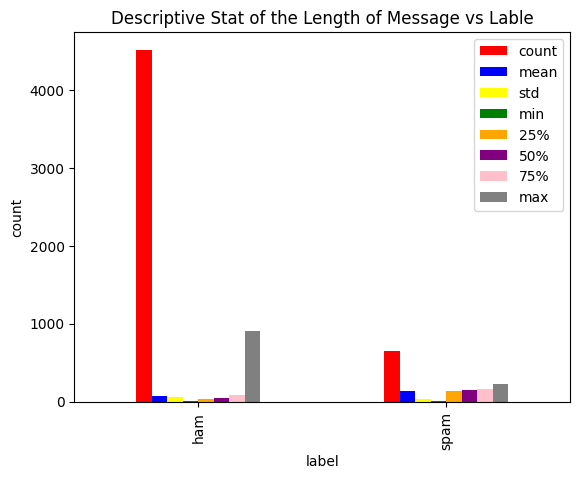

In [ ]:
df_sm.groupby('label')['message_lenght'].describe().plot(
    kind='bar',
    title='Descriptive Stat of the Length of Message vs Lable',
    color=['red', 'blue', 'yellow', 'green', 'orange', 'purple', 'pink', 'grey']
)
plt.xlabel('label')
plt.ylabel('count')
plt.show()

In [ ]:
''' Applying lemmatization to remove common in order to reduce noise from the
dataset for the model to be able to focus on the important details'''

nlp = spacy.load('en_core_web_sm')

def preprocessing_text(text):
  doc = nlp(text)
  tokens = [
      token.lemma_.lower()
      for token in doc
      if not token.is_stop
      and not token.is_punct
      and token.is_alpha
  ]
  return " ".join(tokens)

In [ ]:
df_sm['clean_message'] = df_sm['message'].apply(preprocessing_text)

In [ ]:
df_sm.head()

,label,message,message_lenght,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts tex...
3,ham,U dun say so early hor... U c already then say...,49,u dun early hor u c
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think go usf live


In [ ]:
# Splitting the dataset in X and y

X = df_sm['clean_message']
y = df_sm['label']

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
''' Splittin our X and y into train and test datasets.
Where:
test_size is the amout of data set apart for testing our model after which will be unseen to the model doing training and in this case it is set to 0.3 (i.e 30%)
random_state'''

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train_sm.head()

,clean_message
1757,miss ya need ya want ya love ya
1048,walk hour c u doesnåõt care y will not u belie...
4917,sit mu wait suite shower
3113,yes watch footie worried go blow phil neville
2607,yeah lol luckily star role like


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,                            # Limit vocabulary size, keeps only the top 5000 most informative words/phrases
    ngram_range=(1, 2),                           # Include unigram and bigrams too (e.g., "free entry")
    min_df=2,                                     # Ignore terms that appear in fewer than 2 messages
    max_df=0.95                                   # Ignore terms in >95% of documents, such words are too common to be useful
)

X_train_vec=vectorizer.fit_transform(X_train_sm)
X_test_vec=vectorizer.transform(X_test_sm)

In [ ]:
model_params = {
    'lr_model': {
      'model': LogisticRegression(max_iter=1000, random_state=42),
      'params':[
          {'C': [1, 5, 10], 'penalty': ['l1', 'l2'], 'solver': ['saga']},
          {'C': [1, 5, 10], 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.5]},
          {'C': [1, 5, 10], 'penalty': [None], 'solver': ['saga']}]
    },
    'mnb_model': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.01, 0.1, 1, 10, 100],
            'fit_prior': [True, False]
        }
    }
}

In [ ]:
score = []

for model_name, mp in model_params.items():
  clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
  clf.fit(X_train_vec, y_train_sm)
  score.append(
      {
          'model': model_name,
          'best_score': clf.best_score_,
          'best_params': clf.best_params_
      }
  )

df_sm_score = pd.DataFrame(score, columns=['model', 'best_score', 'best_params'])
display(df_sm_score)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,model,best_score,best_params
0,lr_model,0.972362,"{'C': 1, 'penalty': None, 'solver': 'saga'}"
1,mnb_model,0.980652,"{'alpha': 0.1, 'fit_prior': True}"


In [ ]:
model_df_sm = MultinomialNB(alpha=0.01, fit_prior=True)
model_df_sm.fit(X_train_vec, y_train_sm)

MultinomialNB(alpha=0.01)

In [ ]:
prediction_df_sm = model_df_sm.predict(X_test_vec)
prediction_df_sm

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
# Performing evaluation matrix

acc_sm = accuracy_score(y_test_sm, prediction_df_sm)
pre_sm = precision_score(y_test_sm, prediction_df_sm)
rc_sm = recall_score(y_test_sm, prediction_df_sm)
f1_sm = f1_score(y_test_sm, prediction_df_sm)
cm_sm = confusion_matrix(y_test_sm, prediction_df_sm)
cr_sm = classification_report(y_test_sm, prediction_df_sm)

In [ ]:
print('---\n Evaluation Metrics for Spam Messages Dataset\n---')
print(f'Accuracy: {acc_sm}')
print('---\n')
print(f'Precision: {pre_sm}')
print('---\n')
print(f'Recall: {rc_sm}')
print('---\n')
print(f'F1 Score: {f1_sm}')
print('---\n')
print(f'Confusion Matrix: \n{cm_sm}')
print('---\n')
print(f'Classification Report: \n{cr_sm}')

---
 Evaluation Metrics for Spam Messages Dataset
---
Accuracy: 0.9761444229529336
---

Precision: 0.9644670050761421
---

Recall: 0.8636363636363636
---

F1 Score: 0.9112709832134293
---

Confusion Matrix: 
[[1324    7]
 [  30  190]]
---

Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1331
           1       0.96      0.86      0.91       220

    accuracy                           0.98      1551
   macro avg       0.97      0.93      0.95      1551
weighted avg       0.98      0.98      0.98      1551



In [ ]:
df_sm_er = pd.Series({
    'Model': ['MultinomialNB'],
    'Accuracy': [acc_sm],
    'Precision': [pre_sm],
    'Recall': [rc_sm],
    'F1 Score': [f1_sm]
})

df_sm_er

,0
Model,[MultinomialNB]
Accuracy,[0.9761444229529336]
Precision,[0.9644670050761421]
Recall,[0.8636363636363636]
F1 Score,[0.9112709832134293]


##Fraud Detection Dataset

In [ ]:
# This the dataset for fraud dection. The 'fd' means Fraud Detection.

df_fd = pd.read_csv('Fraud Detection Dataset.csv')

In [ ]:
# Displaying the first five rows in the fraud detection dataset

df_fd.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [ ]:
df_fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [ ]:
df_fd.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,2520
Transaction_Type,0
Time_of_Transaction,2552
Device_Used,2473
Location,2547
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [ ]:
df_fd.dropna(inplace=True)

In [ ]:
df_fd.duplicated().sum()

np.int64(688)

In [ ]:
df_fd.drop_duplicates(inplace=True)

In [ ]:
df_fd.shape

(38895, 12)

In [ ]:
df_fd.size

466740

In [ ]:
df_fd.describe(include='all')

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,38895,38895.000000,38895.00000,38895,38895.000000,38895,38895,38895.000000,38895.000000,38895.000000,38895,38895.000000
unique,38796,NaN,NaN,5,NaN,4,8,NaN,NaN,NaN,5,NaN
top,T39507,NaN,NaN,Bank Transfer,NaN,Desktop,Boston,NaN,NaN,NaN,UPI,NaN
freq,2,NaN,NaN,7879,NaN,12628,4951,NaN,NaN,NaN,9573,NaN
mean,NaN,3005.945366,2997.43836,NaN,11.460213,NaN,NaN,1.996426,59.932356,7.496053,NaN,0.048824
std,NaN,1153.693224,5063.08500,NaN,6.912451,NaN,NaN,1.414509,34.329555,4.018031,NaN,0.215502
min,NaN,1000.000000,5.03000,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,2009.000000,1267.43500,NaN,5.000000,NaN,NaN,1.000000,30.000000,4.000000,NaN,0.000000
50%,NaN,2994.000000,2521.49000,NaN,11.000000,NaN,NaN,2.000000,60.000000,7.000000,NaN,0.000000
75%,NaN,4008.500000,3779.16500,NaN,17.000000,NaN,NaN,3.000000,90.000000,11.000000,NaN,0.000000


In [ ]:
df_fd.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
5,T6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0


In [ ]:
df_fd.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [ ]:
''' Display the number of fraudulent and non-fraudulent transactions
 in the dataset. Where 0 represent non-fraudulent transaction
 and 1 represent fraudulent transaction'''

df_fd['Fraudulent'].value_counts()

,count
Fraudulent,
0,36996
1,1899


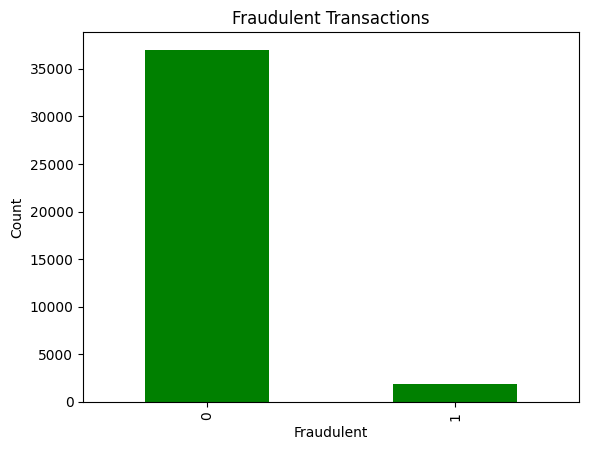

In [ ]:
df_fd['Fraudulent'].value_counts().plot(kind='bar', title='Fraudulent Transactions', color='green')
plt.xlabel('Fraudulent')
plt.ylabel('Count')
plt.show()

In [ ]:
''' Display the number of transaction type in the dataset.'''

df_fd['Transaction_Type'].value_counts()

,count
Transaction_Type,
Bank Transfer,7879
Bill Payment,7829
ATM Withdrawal,7744
POS Payment,7735
Online Purchase,7708


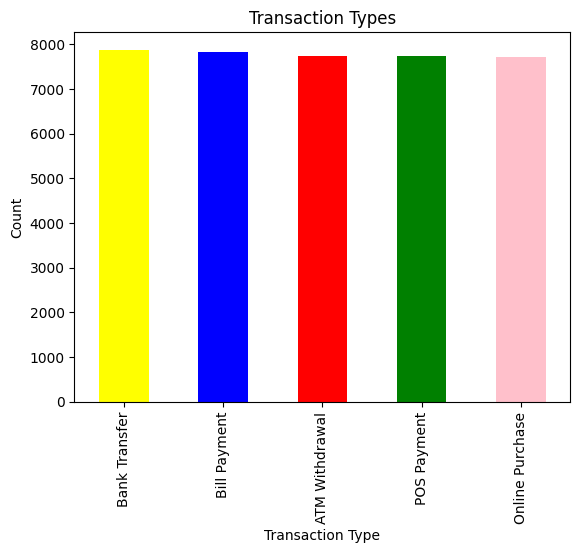

In [ ]:
''' We plot a barchart graph to visualize the Transaction Type
for better understanding.'''

df_fd['Transaction_Type'].value_counts().plot(kind='bar', title='Transaction Types', color=['yellow', 'blue', 'red', 'green', 'pink'] )
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [ ]:
# the amount of fraud that occurs through each transaction type
df_fd.groupby('Transaction_Type')['Fraudulent'].value_counts()

Transaction_Type  Fraudulent
ATM Withdrawal    0             7384
                  1              360
Bank Transfer     0             7497
                  1              382
Bill Payment      0             7438
                  1              391
Online Purchase   0             7323
                  1              385
POS Payment       0             7354
                  1              381
Name: count, dtype: int64

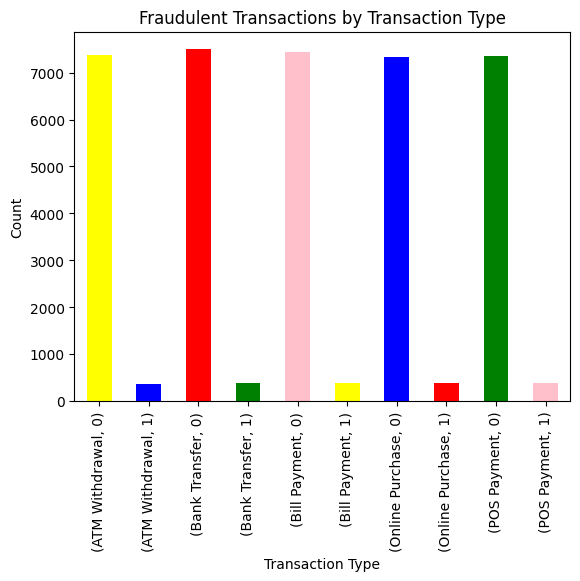

In [ ]:
df_fd.groupby('Transaction_Type')['Fraudulent'].value_counts().plot(kind='bar', title='Fraudulent Transactions by Transaction Type', color=['yellow', 'blue', 'red', 'green', 'pink'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [ ]:
df_fd['Transaction_Amount'].describe().astype(int)

,Transaction_Amount
count,38895
mean,2997
std,5063
min,5
25%,1267
50%,2521
75%,3779
max,49997


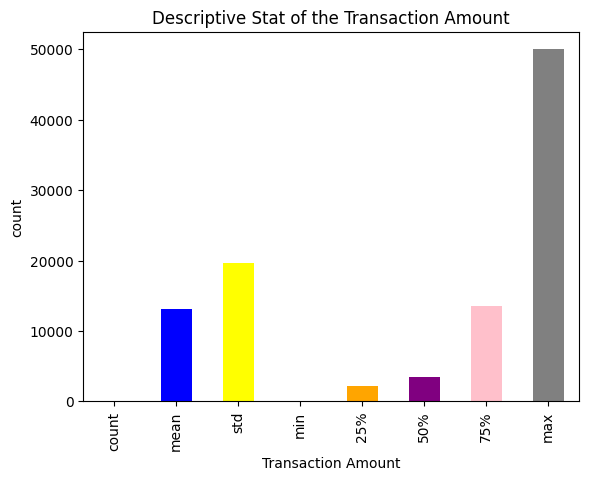

In [ ]:
df_fd['Transaction_Amount'].describe().describe().plot(
    kind='bar',
    title='Descriptive Stat of the Transaction Amount',
    color=['red', 'blue', 'yellow', 'green', 'orange', 'purple', 'pink', 'grey']
)
plt.xlabel('Transaction Amount')
plt.ylabel('count')
plt.show()

In [ ]:
df_fd['Payment_Method'].value_counts()

,count
Payment_Method,
UPI,9573
Debit Card,9468
Net Banking,9339
Credit Card,9287
Invalid Method,1228


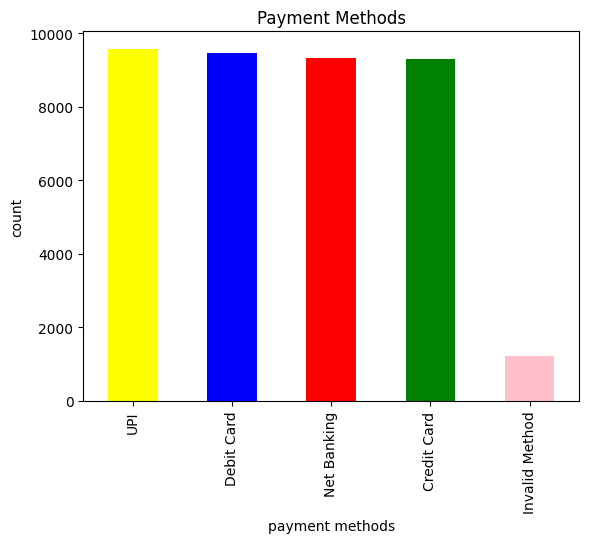

In [ ]:
df_fd['Payment_Method'].value_counts().plot(kind='bar', title='Payment Methods', color=['yellow', 'blue', 'red', 'green', 'pink'])
plt.xlabel('payment methods')
plt.ylabel('count')
plt.show()

In [ ]:
df_fd.groupby('Payment_Method')['Fraudulent'].value_counts()

Payment_Method  Fraudulent
Credit Card     0             8836
                1              451
Debit Card      0             9012
                1              456
Invalid Method  0             1172
                1               56
Net Banking     0             8876
                1              463
UPI             0             9100
                1              473
Name: count, dtype: int64

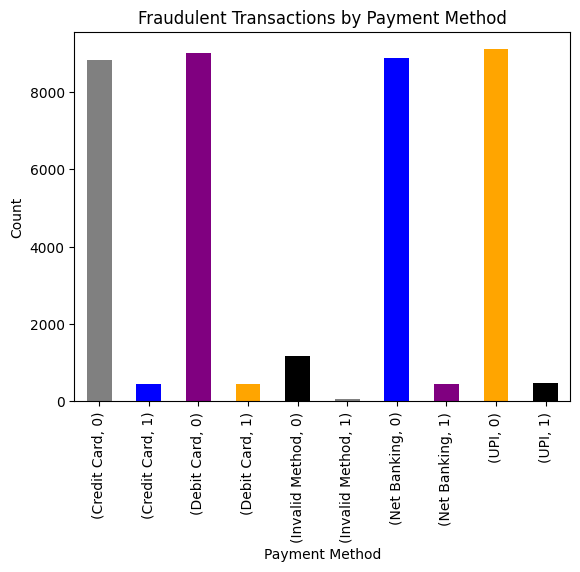

In [ ]:
df_fd.groupby('Payment_Method')['Fraudulent'].value_counts().plot(kind='bar', title='Fraudulent Transactions by Payment Method', color=['grey', 'blue', 'purple', 'orange', 'black'])
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [ ]:
df_fd.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [ ]:
df_fd

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
5,T6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50947,T44210,2798,1073.04,Bill Payment,14.0,Desktop,Houston,0,94,3,Credit Card,0
50975,T44680,4877,1826.49,POS Payment,10.0,Desktop,Houston,1,91,4,Net Banking,0
50985,T39758,2029,544.53,Bank Transfer,14.0,Unknown Device,Chicago,4,59,12,Debit Card,0
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0


In [ ]:
df_fd['Device_Used'].value_counts()

,count
Device_Used,
Desktop,12628
Tablet,12536
Mobile,12494
Unknown Device,1237


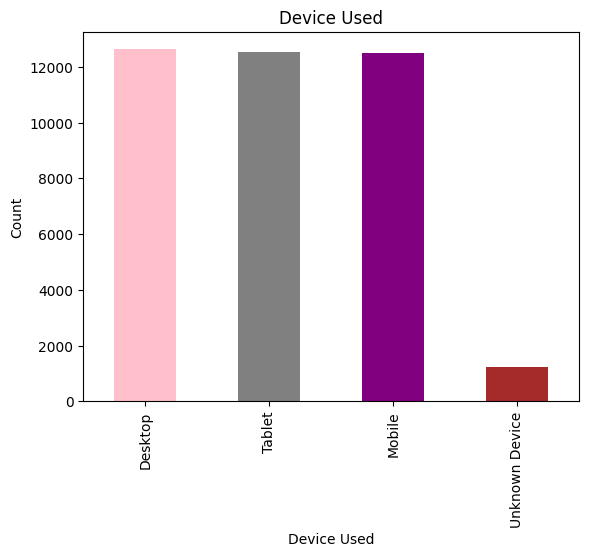

In [ ]:
df_fd['Device_Used'].value_counts().plot(kind='bar', title='Device Used', color=['pink', 'grey', 'purple', 'brown'])
plt.xlabel('Device Used')
plt.ylabel('Count')
plt.show()

In [ ]:
df_fd.groupby('Device_Used')['Fraudulent'].value_counts()

Device_Used     Fraudulent
Desktop         0             12027
                1               601
Mobile          0             11847
                1               647
Tablet          0             11941
                1               595
Unknown Device  0              1181
                1                56
Name: count, dtype: int64

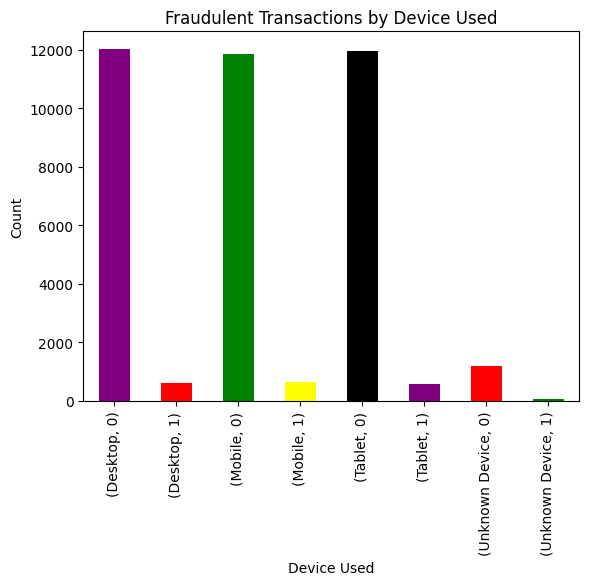

In [ ]:
df_fd.groupby('Device_Used')['Fraudulent'].value_counts().plot(kind='bar', title='Fraudulent Transactions by Device Used', color=['purple', 'red', 'green', 'yellow', 'black'])
plt.xlabel('Device Used')
plt.ylabel('Count')
plt.show()

## Feature Engineering Process

In [ ]:
# Converting the time to be continuous in order to make the model understand the cyclical nature of time.

df_fd['hour_sin'] = np.sin(2 * np.pi*df_fd['Time_of_Transaction']/24)
df_fd['hour_cos'] = np.cos(2*np.pi*df_fd['Time_of_Transaction']/24)

In [ ]:
''' We are encoding the columns that are objects but needed in training our model. This columns are:
- Transaction_Type
- Payment_Method
'''
df_fd['Transaction_Type'] = df_fd['Transaction_Type'].map({'Bank Transfer':0,'Bill Payment': 1, 'ATM Withdrawal': 2, 'POS Payment': 3, 'Online Purchase': 4})
df_fd['Payment_Method'] = df_fd['Payment_Method'].map({'Credit Card': 0, 'Debit Card': 1, 'Invalid Method': 2, 'Net Banking': 3, 'UPI': 4})
df_fd['Device_Used'] = df_fd['Device_Used'].map({'Desktop':0, 'Mobile':1, 'Tablet':2, 'Unknown Device':3})

In [ ]:
df_fd.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,hour_sin,hour_cos
0,T1,4174,1292.76,2,16.0,2,San Francisco,0,119,13,1,0,-0.866025,-0.500000
1,T2,4507,1554.58,2,13.0,1,New York,4,79,3,0,0,-0.258819,-0.965926
3,T4,2294,100.10,1,15.0,0,Chicago,4,3,4,4,0,-0.707107,-0.707107
4,T5,2130,1490.50,3,19.0,1,San Francisco,2,57,7,0,0,-0.965926,0.258819
5,T6,2095,2372.04,2,15.0,0,Boston,3,96,14,0,0,-0.707107,-0.707107


In [ ]:
X = df_fd.drop(['Transaction_ID', 'Location', 	'Time_of_Transaction', 'Fraudulent'], axis=1)
y = df_fd['Fraudulent']

In [ ]:
X.head()

,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,hour_sin,hour_cos
0,4174,1292.76,2,2,0,119,13,1,-0.866025,-0.500000
1,4507,1554.58,2,1,4,79,3,0,-0.258819,-0.965926
3,2294,100.10,1,0,4,3,4,4,-0.707107,-0.707107
4,2130,1490.50,3,1,2,57,7,0,-0.965926,0.258819
5,2095,2372.04,2,0,3,96,14,0,-0.707107,-0.707107


In [ ]:
y.head()

,Fraudulent
0,0
1,0
3,0
4,0
5,0


In [ ]:
X_train_fd, X_test_fd, y_train_fd, y_test_fd = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_fd.head()

,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,hour_sin,hour_cos
2505,1241,1988.75,2,0,4,21,14,3,-0.500000,-0.866025
29037,2884,2999.30,1,1,3,67,4,3,0.866025,-0.500000
2735,4192,1996.48,2,0,2,43,7,0,-0.965926,-0.258819
21599,4281,4032.08,0,1,4,29,9,0,-0.500000,0.866025
43064,2629,4313.10,3,1,4,25,2,3,-0.965926,-0.258819


In [ ]:
model_params = {
    'rf_model': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'xbg_model': {
        'model': XGBClassifier(),
        'params':{
            'gamma': [0, 0.1, 0.2],
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30],
            'learning_rate': [0.3, 0.5, 0.7]

        }
    }
}

In [ ]:
score = []

for model_name, mp in model_params.items():
  clf = RandomizedSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
  clf.fit(X_train_fd, y_train_fd)
  score.append(
      {
          'model': model_name,
          'best_score': clf.best_score_,
          'best_params': clf.best_params_,
          'mean_test_score': clf.cv_results_['mean_test_score'][clf.best_index_]
      }
  )

# Create and display the DataFrame outside the loop to include all model scores
df = pd.DataFrame(score, columns=['model', 'best_params', 'best_score', 'mean_test_score'])
df

,model,best_params,best_score,mean_test_score
0,rf_model,"{'n_estimators': 100, 'min_samples_split': 10,...",0.950861,0.950861
1,xbg_model,"{'n_estimators': 300, 'max_depth': 20, 'learni...",0.950604,0.950604


In [ ]:
score

[{'model': 'rf_model',
  'best_score': np.float64(0.9508612940550994),
  'best_params': {'n_estimators': 100,
   'min_samples_split': 10,
   'min_samples_leaf': 2,
   'max_depth': 10},
  'mean_test_score': np.float64(0.9508612940550994)},
 {'model': 'xbg_model',
  'best_score': np.float64(0.9506042091552731),
  'best_params': {'n_estimators': 300,
   'max_depth': 20,
   'learning_rate': 0.3,
   'gamma': 0.2},
  'mean_test_score': np.float64(0.9506042091552731)}]

In [ ]:
model = RandomForestClassifier(n_estimators= 200, min_samples_split= 2, min_samples_leaf= 2, max_depth= 20, class_weight='balanced')
model.fit(X_train_fd, y_train_fd)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, n_estimators=200)

In [ ]:
predictions_fd = model.predict(X_test_fd)

In [ ]:
# Get probability predictions from the model
predictions_proba_fd = model.predict_proba(X_test_fd)

# We are interested in the probability of the positive class (class 1)
predictions_proba_positive_fd = predictions_proba_fd[:, 1]

# Define a custom threshold (e.g., 0.3). You can adjust this value.
threshold = 0.3

# Apply the custom threshold to classify transactions
predictions_fd_thresholded = (predictions_proba_positive_fd >= threshold).astype(int)

print(f"Predictions with a threshold of {threshold}:")
print(predictions_fd_thresholded)

Predictions with a threshold of 0.3:
[0 0 0 ... 0 0 0]


Now, let's re-evaluate the model's performance using these thresholded predictions.

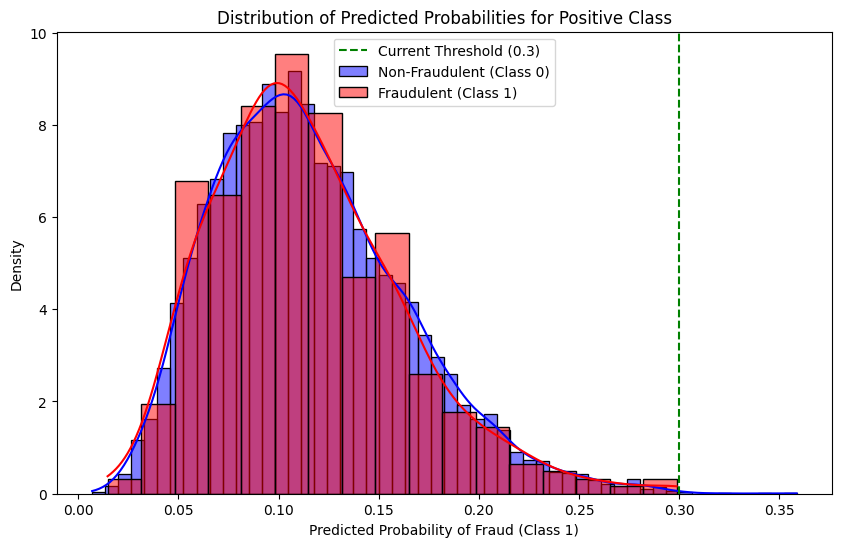

In [ ]:
# Let's examine the distribution of predicted probabilities for the positive class
plt.figure(figsize=(10, 6))
sns.histplot(predictions_proba_positive_fd[y_test_fd == 0], color='blue', label='Non-Fraudulent (Class 0)', kde=True, stat='density', alpha=0.5)
sns.histplot(predictions_proba_positive_fd[y_test_fd == 1], color='red', label='Fraudulent (Class 1)', kde=True, stat='density', alpha=0.5)
plt.axvline(x=threshold, color='green', linestyle='--', label=f'Current Threshold ({threshold})')
plt.title('Distribution of Predicted Probabilities for Positive Class')
plt.xlabel('Predicted Probability of Fraud (Class 1)')
plt.ylabel('Density')
plt.legend()
plt.show()

This plot will help us visualize how well the model is separating the two classes based on their predicted probabilities and inform whether adjusting the threshold further makes sense, or if the model itself needs more fundamental changes or different features.

In [ ]:
acc_fd = accuracy_score(y_test_fd, predictions_fd)
pre_fd = precision_score(y_test_fd, predictions_fd)
rec_fd = recall_score(y_test_fd, predictions_fd)
f1_fd = f1_score(y_test_fd, predictions_fd)
cm_fd = confusion_matrix(y_test_fd, predictions_fd)
cr_fd = classification_report(y_test_fd, predictions_fd)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
acc_fd

0.952436045764237

In [ ]:
model_xgb = XGBClassifier(n_estimators= 300, max_depth= 20, learning_rate= 0.3, gamma= 0.2)
model_xgb.fit(X_train_fd, y_train_fd)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
prediction_xgb = model_xgb.predict(X_test_fd)

In [ ]:
acc_xgb = accuracy_score(y_test_fd, prediction_xgb)
pre_xgb = precision_score(y_test_fd, prediction_xgb)
rec_xgb = recall_score(y_test_fd, prediction_xgb)
f1_xgb = f1_score(y_test_fd, prediction_xgb)
cm_xgb = confusion_matrix(y_test_fd, prediction_xgb)
cf_xgb = classification_report(y_test_fd, prediction_xgb)

In [ ]:
print('---\nEvaluation Metrics for Fraud Detection Dataset\n---')
print(f'Accuracy: {acc_fd}')
print(f'Precision: {pre_fd}')
print(f'Recall: {rec_fd}')
print(f'F1 Score: {f1_fd}')
print(f'Confusion Matrix: \n{cm_fd}')
print(f'Classification Report: \n{cr_fd}')

---
Evaluation Metrics for Fraud Detection Dataset
---
Accuracy: 0.952436045764237
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix: 
[[7409    0]
 [ 370    0]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      7409
           1       0.00      0.00      0.00       370

    accuracy                           0.95      7779
   macro avg       0.48      0.50      0.49      7779
weighted avg       0.91      0.95      0.93      7779

